Расстояния между центрами:
 [0.61093732 0.61049829 0.60975319 0.60885115 0.60798117 0.60734475
 0.60710708 0.60732826 0.6079302  0.60873977 0.60955826 0.61020529
 0.61054328] 
диаметр = 0.6


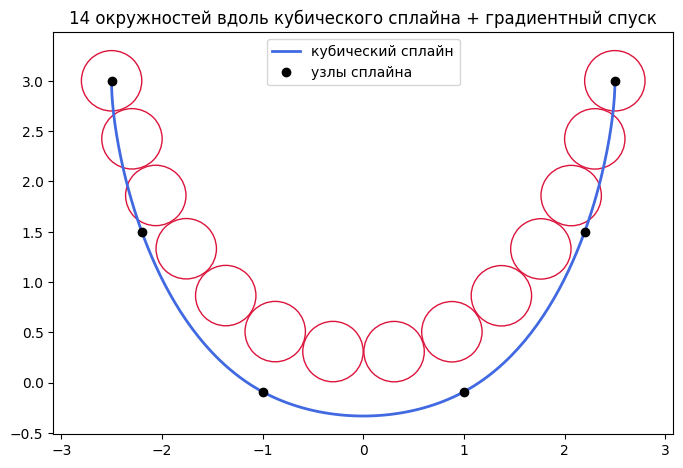

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.interpolate import make_interp_spline

# Параметры
n_teeth = 14
radius = 0.3
corr_flag = 1

# --- Шаг 1: выбираем узлы для сплайна ---
# сделаем мета координаты точек одной половины сплайна (правой)
sp_p1 = 2.5, 3
sp_p2 = 2.2, 1.5
sp_p3 = 1, -0.09

indices = [0, 2, 4, 9, 11, 13]
spline_points = np.array([[-sp_p1[0], sp_p1[1]], 
                          [-sp_p2[0], sp_p2[1]], 
                          [-sp_p3[0], sp_p3[1]], 
                          [sp_p3[0],  sp_p3[1]], 
                          [sp_p2[0],  sp_p2[1]], 
                          [sp_p1[0],  sp_p1[1]]])  # симметричные точки
x = spline_points[:,0]
y = spline_points[:,1]

# --- Шаг 2: строим кубический интерполяционный сплайн ---
u = np.arange(len(indices))  # параметризация по индексу
spl_x = make_interp_spline(u, spline_points[:,0], k=3)
spl_y = make_interp_spline(u, spline_points[:,1], k=3)

# spl = make_interp_spline(x, y, k=3)

u_new = np.linspace(u.min(), u.max(), 200)
x_curve = spl_x(u_new)
y_curve = spl_y(u_new)

# x_new = np.linspace(x.min(), x.max(), 200)
# y_new = spl(x_new)

# --- Шаг 3: пересчитываем центры окружностей вдоль сплайна ---
u_circle = np.linspace(u.min(), u.max(), n_teeth)
centers = np.column_stack([spl_x(u_circle), spl_y(u_circle)])

# _centers = np.column_stack([u_circle, spl(u_circle)])

# --- Функция стоимости ---
def cost(centers):
    d = np.linalg.norm(np.diff(centers, axis=0), axis=1)
    return np.sum((d - 2*radius)**2)

# --- Итеративная коррекция (градиентный спуск) ---
def dist_resolve(centers: np.ndarray, _range=500, radius=1.1) -> np.ndarray:
    accuracy = 0.001
    lr = 0.1
    for step in range(_range):
        for i in range(1, n_teeth-1):  # внутренние точки
            left_dist = np.linalg.norm(centers[i] - centers[i-1])
            right_dist = np.linalg.norm(centers[i] - centers[i+1])
            
            grad = (left_dist - 2*radius) * (centers[i] - centers[i-1]) / (left_dist+1e-6) \
                 + (right_dist - 2*radius) * (centers[i] - centers[i+1]) / (right_dist+1e-6)
            
            centers[i] -= lr * grad
        if cost(centers) < accuracy:
            print(f"stops iterating on step {step}")
            break
    return centers

# --- Запускаем коррекцию ---
if corr_flag:
    centers = dist_resolve(centers, radius=radius)

# --- Проверка расстояний ---
dists = np.linalg.norm(np.diff(centers, axis=0), axis=1)
print("Расстояния между центрами:\n", dists, "\nдиаметр =", 2*radius)


# --- Визуализация ---
fig, ax = plt.subplots(figsize=(8,6))
ax.set_aspect('equal')

# Сплайн
ax.plot(x_curve, y_curve, 'royalblue', lw=2, label="кубический сплайн")

# Окружности
for c in centers:
    ax.add_patch(Circle(c, radius, edgecolor='crimson', facecolor='none'))

# Узлы сплайна
ax.plot(spline_points[:,0], spline_points[:,1], 'o', color='black', label="узлы сплайна")

ax.set_title("14 окружностей вдоль кубического сплайна + градиентный спуск")
ax.legend()
plt.show()


обновление алгоритма - убираем радиусы окружностей из градиента и функции стоимости.   
радиусы при этом случайны

stops iterating on step 515
целевые = [0.6963, 0.597, 0.5258, 0.5956, 0.6502, 0.6029, 0.5455, 0.5939, 0.594, 0.5772, 0.5681, 0.6111, 0.6212]
макс дельта = 0.0107
средняя дельта = 0.00868


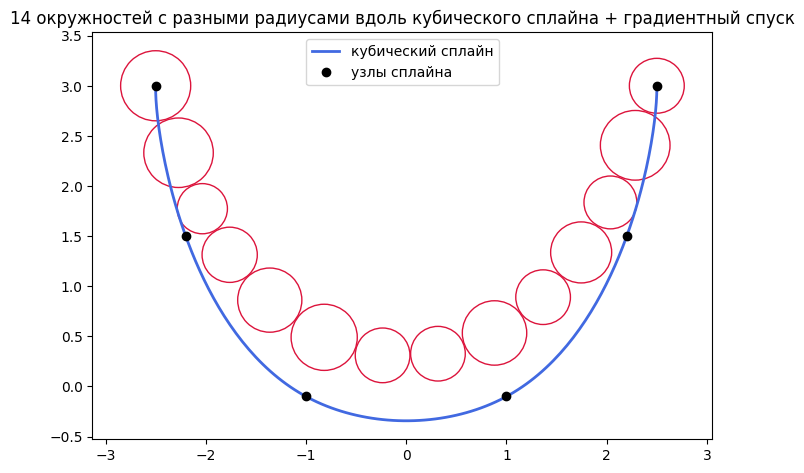

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.interpolate import make_interp_spline
import random 

# Параметры
n_teeth = 14
radius_base = 0.3
corr_flag = 1

# делаем разные радиусы - добавляем к базовому случайные числа
distors = 0.05
radiuses = [radius_base + random.uniform(-distors, distors) for _ in range(n_teeth)]
target_dists = [radiuses[i] + radiuses[i+1] for i in range(n_teeth-1)]

# --- Шаг 1: узлы для сплайна ---
sp_p1 = 2.5, 3
sp_p2 = 2.2, 1.5
sp_p3 = 1, -0.1

indices = [0, 2, 4, 9, 11, 13]
spline_points = np.array([[-sp_p1[0], sp_p1[1]], 
                          [-sp_p2[0], sp_p2[1]], 
                          [-sp_p3[0], sp_p3[1]], 
                          [ sp_p3[0], sp_p3[1]], 
                          [ sp_p2[0], sp_p2[1]], 
                          [ sp_p1[0], sp_p1[1]]])  # симметричные точки
x = spline_points[:,0]
y = spline_points[:,1]

# --- Шаг 2: кубический сплайн ---
u = np.arange(len(indices))
spl_x = make_interp_spline(u, spline_points[:,0], k=3)
spl_y = make_interp_spline(u, spline_points[:,1], k=3)

u_new = np.linspace(u.min(), u.max(), 200)
x_curve = spl_x(u_new)
y_curve = spl_y(u_new)

# --- Шаг 3: центры окружностей вдоль сплайна ---
u_circle = np.linspace(u.min(), u.max(), n_teeth)
centers = np.column_stack([spl_x(u_circle), spl_y(u_circle)])

# --- Функция стоимости ---
def cost(centers, target_dists):
    d = np.linalg.norm(np.diff(centers, axis=0), axis=1)
    return np.sum((d - target_dists)**2)

# --- Итеративная коррекция ---
def dist_resolve(centers: np.ndarray, target_dists, _range=1000) -> np.ndarray:
    accuracy = 0.001
    lr = 0.1
    for step in range(_range):
        for i in range(1, n_teeth-1):  # внутренние точки
            left_dist = np.linalg.norm(centers[i] - centers[i-1])
            right_dist = np.linalg.norm(centers[i] - centers[i+1])
            
            grad = (left_dist - target_dists[i-1]) * (centers[i] - centers[i-1]) / (left_dist+1e-6) \
                 + (right_dist - target_dists[i])   * (centers[i] - centers[i+1]) / (right_dist+1e-6)
            
            centers[i] -= lr * grad
        if cost(centers, target_dists) < accuracy:
            print(f"stops iterating on step {step}")
            break
    return centers

# --- Запуск коррекции ---
if corr_flag:
    centers = dist_resolve(centers, target_dists)

# --- Проверка расстояний ---
dists = np.linalg.norm(np.diff(centers, axis=0), axis=1)
max_delta = np.max(np.abs(dists - target_dists))
mean_delta = np.mean(np.abs(dists - target_dists))

print(f"целевые = {[round(i, 4) for i in target_dists]}")
print(f"макс дельта = {max_delta:.3}")
print(f"средняя дельта = {mean_delta:.3}")

# --- Визуализация ---
fig, ax = plt.subplots(figsize=(8,6))
ax.set_aspect('equal')

# Сплайн
ax.plot(x_curve, y_curve, 'royalblue', lw=2, label="кубический сплайн")

# Окружности с индивидуальными радиусами
for c, r in zip(centers, radiuses):
    ax.add_patch(Circle(c, r, edgecolor='crimson', facecolor='none'))

# Узлы сплайна
ax.plot(spline_points[:,0], spline_points[:,1], 'o', color='black', label="узлы сплайна")

ax.set_title("14 окружностей с разными радиусами вдоль кубического сплайна + градиентный спуск")
ax.legend()
plt.show()


не работающий вариант с попыткой добавки к градиенту компонента с растонием до сплайна. возможно проблема в том как считается расстояние до сплайна 

TODO надо это расстояние попробовать визуализировать

Расстояния между центрами:
 [0.68024745 0.72627462 0.77301661 0.79709807 0.79425883 0.77740422
 0.76825416 0.77740422 0.79425883 0.79709807 0.77301661 0.72627462
 0.68024745] 
диаметр = 0.7
макс дельта = 0.0971


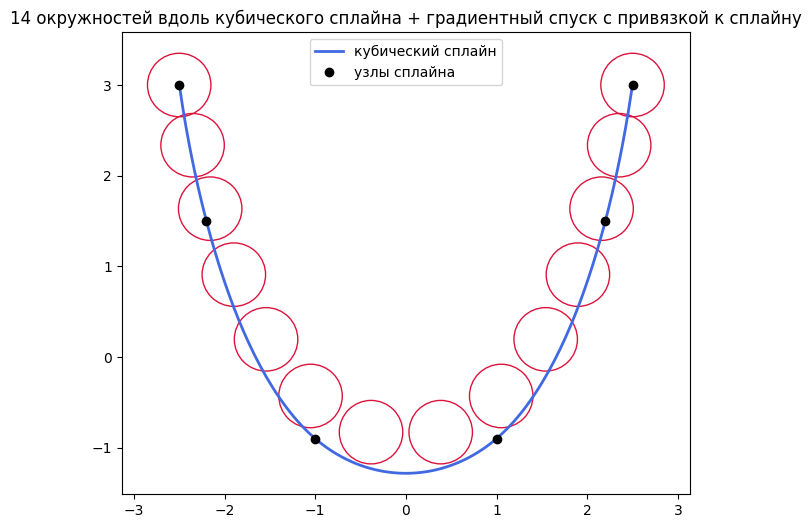

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.interpolate import make_interp_spline

# Параметры
n_teeth = 14
radius = 0.35
# вес привязки к сплайну в функции стоимости
lambda_spline = 0.1  
# флаг включения коррекции
corr_flag = 1

# --- Шаг 1: узлы для сплайна ---
# сделаем мета координаты точек одной половины сплайна (правой)
sp_p1 = 2.5, 3
sp_p2 = 2.2, 1.5
sp_p3 = 1, -0.9

indices = [0, 2, 4, 9, 11, 13]
spline_points = np.array([[-sp_p1[0], sp_p1[1]], 
                          [-sp_p2[0], sp_p2[1]], 
                          [-sp_p3[0], sp_p3[1]], 
                          [sp_p3[0],  sp_p3[1]], 
                          [sp_p2[0],  sp_p2[1]], 
                          [sp_p1[0],  sp_p1[1]]])  # симметричные точки
x = spline_points[:,0]
y = spline_points[:,1]

# --- Шаг 2: кубический интерполяционный сплайн ---
u = np.arange(len(indices))
spl_x = make_interp_spline(u, spline_points[:,0], k=3)
spl_y = make_interp_spline(u, spline_points[:,1], k=3)

u_new = np.linspace(u.min(), u.max(), 200)
x_curve = spl_x(u_new)
y_curve = spl_y(u_new)

# --- Шаг 3: центры окружностей вдоль сплайна ---
u_circle = np.linspace(u.min(), u.max(), n_teeth)
centers = np.column_stack([spl_x(u_circle), spl_y(u_circle)])

# --- Функция стоимости ---
def cost(centers, radius, u_circle, lambda_spline=0.1):
    # коллизии
    d = np.linalg.norm(np.diff(centers, axis=0), axis=1)
    collision_term = np.sum((d - 2*radius)**2)
    # расстояние до сплайна
    spline_points = np.column_stack([spl_x(u_circle), spl_y(u_circle)])
    dist_to_spline = np.linalg.norm(centers - spline_points, axis=1)
    spline_term = np.sum(dist_to_spline**2)
    return collision_term + lambda_spline * spline_term

# --- Итеративная коррекция ---
def dist_resolve(centers: np.ndarray, u_circle, _range=5000, radius=0.37, lambda_spline=0.1) -> np.ndarray:
    accuracy = 0.001
    spline_points = np.column_stack([spl_x(u_circle), spl_y(u_circle)])
    lr = 0.1
    for step in range(_range):
        for i in range(1, n_teeth-1):  # внутренние точки
            left_dist = np.linalg.norm(centers[i] - centers[i-1])
            right_dist = np.linalg.norm(centers[i] - centers[i+1])
            
            grad_collision = (left_dist - 2*radius) * (centers[i] - centers[i-1]) / (left_dist+1e-6) \
                           + (right_dist - 2*radius) * (centers[i] - centers[i+1]) / (right_dist+1e-6)
            
            # градиент по расстоянию до сплайна
            grad_spline = centers[i] - spline_points[i]
            
            grad = grad_collision + lambda_spline * grad_spline
            centers[i] -= lr * grad
        
        if cost(centers, radius, u_circle, lambda_spline) < accuracy:
            print(f"stops iterating on step {step}")
            break
    
    return centers

# --- Запускаем коррекцию ---
if corr_flag:
    centers = dist_resolve(centers, u_circle, radius=radius, 
                        lambda_spline=lambda_spline
                        )

# --- Проверка расстояний ---
dists = np.linalg.norm(np.diff(centers, axis=0), axis=1)
print("Расстояния между центрами:\n", dists, "\nдиаметр =", 2*radius)
print(f"макс дельта = {np.max(np.abs(dists - 2*radius)):.3}")

# --- Визуализация ---
fig, ax = plt.subplots(figsize=(8,6))
ax.set_aspect('equal')

# Сплайн
ax.plot(x_curve, y_curve, 'royalblue', lw=2, label="кубический сплайн")

# Окружности
for c in centers:
    ax.add_patch(Circle(c, radius, edgecolor='crimson', facecolor='none'))

# Узлы сплайна
ax.plot(spline_points[:,0], spline_points[:,1], 'o', color='black', label="узлы сплайна")

ax.set_title("14 окружностей вдоль кубического сплайна + градиентный спуск с привязкой к сплайну")
ax.legend()
plt.show()
